In [ ]:
# create and save PSTH
from nwb_utils import NWBUtils
from behavior_utils import extract_fitted_data, find_trials,get_fitted_model_names,generate_behavior_summary
from create_psth import extract_neuron_psth_to_zarr

session_name = 'ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28'
nwb_data,tag=NWBUtils.combine_nwb(session_name=session_name)

psth_da = extract_neuron_psth_to_zarr(
    nwb_data       = nwb_data,
    align_to_event = ["go_cue","reward_go_cue_start"],
    time_window    = (-3, 4),
    bin_size       = 0.2,
    save_folder    = "/root/capsule/scratch",
    save_name      = "ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_0.2s.zarr",
)

In [ ]:
# train single sessions


# load one session
import numpy as np
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions
from general_visualization import plot_behavior_session
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names
from general_utils import find_behavior_sessions

binsize='0.2'
sessions = find_ephys_sessions()
session = sessions[2][14]
session = 'ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28'
psth_da = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
df = smart_read_csv(f"/root/capsule/scratch/behavior_summary-{session}.csv")
nwb_data_behavior=NWBUtils.read_behavior_nwb(session_name=session)
plot_behavior_session(nwb_data=nwb_data_behavior,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')
nwb_data,tag=NWBUtils.combine_nwb(session_name=session)

In [127]:
# -*- coding: utf-8 -*-
"""
Trial-wise Full-FORCE (RLS) — "optimal per trial" with warm starts
------------------------------------------------------------------
• Trains a separate network for every trial.
• Trial k starts from W learned on trial k-1 (warm start).
• Within each trial, reset RLS covariance P (optimal for that trial).
• Win is ridge-fit each trial (or you can keep it fixed).
• Optional PSTH smoothing before training.

Included:
- prepare_random_units_for_force
- scale_psth_to_tanh_percentile / invert_tanh_scaling
- build_trial_inputs (6 channels)
- rnn_forward
- fullforce_trialwise_optimal (main trainer)
- Smoothing helpers (gaussian / moving-average)
- Ridge-fit helper for Win
- Plot helpers:
  * plot_inputs_for_trial
  * plot_trial_reconstruction
  * plot_fit_summary
  * plot_r2_histogram
  * plot_learning_curves
  * plot_intra_trial_error_series
  * plot_W_row_norms_snapshots
  * plot_fit_summary_with_original
  * plot_fit_summary_with_original_from_result
"""

from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple, Sequence
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# 0) Data selection: randomly sample units for FORCE
# =============================================================================

def prepare_random_units_for_force(
    psth_da: "xr.Dataset | xr.DataArray",
    var_name: str = "psth_go_cue",
    n_select: int = 200,
    seed: int = 42,
    unit_coord: str = "unit",          # source dimension name if not unit_index
    target_unit_dim: str = "unit_index",
    time_coord: str = "time",
) -> Tuple[np.ndarray, np.ndarray, "xr.DataArray", np.ndarray]:
    """
    Returns (Y_trials, t_rel, psth_da_sub, selected_units)

    Y_trials : (units, time, trials)
    t_rel    : (time,)
    """
    import xarray as xr
    da = psth_da[var_name] if isinstance(psth_da, xr.Dataset) else psth_da

    # Ensure dimension is named unit_index for sampling
    if target_unit_dim not in da.dims:
        if unit_coord in da.dims or unit_coord in da.coords:
            da = da.swap_dims({unit_coord: target_unit_dim})
        else:
            raise ValueError(f"Could not find '{target_unit_dim}' or '{unit_coord}' in dims/coords.")

    da = da.sortby(target_unit_dim)
    all_units = da.coords[target_unit_dim].values
    rng = np.random.default_rng(seed)
    selected_units = rng.choice(all_units, size=min(n_select, len(all_units)), replace=False)

    da_sub = da.sel({target_unit_dim: selected_units})

    # infer trial dimension (the one that's not unit_index or time)
    other_dims = [d for d in da_sub.dims if d not in (target_unit_dim, time_coord)]
    if len(other_dims) != 1:
        raise ValueError(f"Ambiguous trial dimension; found {other_dims}.")
    trial_dim = other_dims[0]

    da_sub = da_sub.transpose(target_unit_dim, time_coord, trial_dim)
    Y_trials = np.asarray(da_sub.values, float)           # (U,T,K)
    t_rel = np.asarray(da_sub.coords[time_coord].values, float)

    if not np.all(np.isfinite(t_rel)) or np.any(np.diff(t_rel) <= 0):
        raise ValueError("time must be strictly increasing and finite.")
    return Y_trials, t_rel, da_sub, selected_units


# =============================================================================
# 1) Scaling utilities (rates <-> tanh)
# =============================================================================

def scale_psth_to_tanh_percentile(
    Y_raw: np.ndarray, lo: float = 1.0, hi: float = 99.0, clip: float = 0.90
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    Y = np.asarray(Y_raw, float)
    base = np.percentile(Y, lo, axis=1, keepdims=True)
    Y0 = np.maximum(Y - base, 0.0)
    scale = np.maximum(np.percentile(Y0, hi, axis=1, keepdims=True), 1e-6)
    Y01 = np.clip(Y0 / scale, 0.0, 1.0)
    Y_sc = (2 * clip) * (Y01 - 0.5)
    return np.clip(Y_sc, -clip, clip), {"baseline": base, "scale": scale, "clip": float(clip)}

def invert_tanh_scaling(Y_sc: np.ndarray, scaler: Dict[str, np.ndarray]) -> np.ndarray:
    c = float(scaler["clip"])
    base, scale = scaler["baseline"], scaler["scale"]
    Y01 = (np.asarray(Y_sc) / (2 * c)) + 0.5
    return Y01 * scale + base


# =============================================================================
# 2) Inputs per trial (6 channels)
# =============================================================================

def build_trial_inputs(
    nwb_data: Any,
    trial_idx: int,
    t_rel: np.ndarray,
    *,
    go_dur=0.2, resp_delay=0.2, resp_dur=0.4, rew_delay=0.2, rew_dur=1.0,
) -> Tuple[np.ndarray, List[str]]:
    ch_names = ["go", "resp_L", "resp_R", "resp_NoResp", "rew_L", "rew_R"]
    C, T = 6, t_rel.size
    U = np.zeros((C, T), dtype=float)
    dt = float(np.median(np.diff(t_rel)))

    def to_idx(t): return int(np.round((t - t_rel[0]) / dt))
    def set_high(ch, a, b):
        i0, i1 = max(0, to_idx(a)), min(T, to_idx(b))
        if i1 > i0: U[ch, i0:i1] = 1.0

    resp = int(nwb_data.trials["animal_response"][trial_idx])  # 0=L,1=R,2=None
    rewL = bool(nwb_data.trials["rewarded_historyL"][trial_idx])
    rewR = bool(nwb_data.trials["rewarded_historyR"][trial_idx])

    set_high(0, 0.0, go_dur)
    r0, r1 = resp_delay, resp_delay + resp_dur
    (set_high(1, r0, r1) if resp == 0 else
     set_high(2, r0, r1) if resp == 1 else
     set_high(3, r0, r1))
    w0, w1 = rew_delay, rew_delay + rew_dur
    if rewL: set_high(4, w0, w1)
    if rewR: set_high(5, w0, w1)
    return U, ch_names


# =============================================================================
# 3) RNN forward
# =============================================================================

def rnn_forward(W: np.ndarray, Win: np.ndarray, U: np.ndarray, tau: float, dt: float, x0=None) -> np.ndarray:
    Uu, T = W.shape[0], U.shape[1]
    x = np.zeros(Uu) if x0 is None else np.array(x0, float)
    r = np.tanh(x)
    R = np.zeros((Uu, T), float)
    a = dt / tau
    for t in range(T):
        x += a * (-x + (W @ r) + (Win @ U[:, t]))
        r = np.tanh(x)
        R[:, t] = r
    return R


# =============================================================================
# 4) Smoothing helpers
# =============================================================================

def _gaussian_kernel(sigma_bins: int) -> np.ndarray:
    sigma_bins = max(1, int(sigma_bins))
    half = int(3 * sigma_bins)           # ~99.7% support
    x = np.arange(-half, half + 1, dtype=float)
    k = np.exp(-0.5 * (x / sigma_bins) ** 2)
    k /= k.sum()
    return k

def _boxcar_kernel(win_bins: int) -> np.ndarray:
    win_bins = max(1, int(win_bins))
    k = np.ones(win_bins, dtype=float)
    k /= k.size
    return k

def _conv1d_same(x: np.ndarray, k: np.ndarray) -> np.ndarray:
    half = (k.size - 1) // 2
    pad = np.pad(x, (half, half), mode="reflect")
    y = np.convolve(pad, k, mode="valid")
    return y

def smooth_trials(
    Y_trials: np.ndarray,   # (U, T, K)
    dt: float,
    *,
    method: str = "gaussian",
    sigma_s: float = 0.2,
    win_s: float = 0.2,
    keep_nonneg: bool = True,
) -> np.ndarray:
    """
    Smooth every (unit, trial) trace along time.
    - 'gaussian': std=sigma_s seconds
    - 'moving_average': width=win_s seconds
    """
    U, T, K = Y_trials.shape
    if method == "gaussian":
        sigma_bins = max(1, int(round(sigma_s / dt)))
        k = _gaussian_kernel(sigma_bins)
    elif method in {"moving_average", "boxcar"}:
        win_bins = max(1, int(round(win_s / dt)))
        k = _boxcar_kernel(win_bins)
    else:
        raise ValueError("method must be 'gaussian' or 'moving_average'")

    Y_sm = np.empty_like(Y_trials, dtype=float)
    for u in range(U):
        for tr in range(K):
            Y_sm[u, :, tr] = _conv1d_same(Y_trials[u, :, tr], k)
    if keep_nonneg:
        np.maximum(Y_sm, 0.0, out=Y_sm)
    return Y_sm


# =============================================================================
# 5) Ridge-fit Win to match desired drive
# =============================================================================

def _ridge_fit_win(D: np.ndarray, U: np.ndarray, lam_win: float = 1.0) -> np.ndarray:
    """
    Ridge-regress Win to match D ≈ Win @ U.
    D: (U_units, T-1), U: (C, T-1)  -> Win: (U_units, C)
    Solves row-wise: min_Win ||D - Win U||_F^2 + lam_win ||Win||_F^2
    """
    C, Tm1 = U.shape
    G = U @ U.T                      # (C,C)
    A = G + lam_win * np.eye(C)
    A_inv = np.linalg.pinv(A)
    Win = (D @ U.T) @ A_inv          # (U_units, C)
    return Win


# =============================================================================
# 6) Data classes
# =============================================================================

@dataclass
class TrialNet:
    W: np.ndarray
    Win: np.ndarray
    scaler: Dict[str, np.ndarray]    # scaler used for that trial (global or per-trial)

@dataclass
class ProgressLogger:
    mse_last_per_trial: List[float] = field(default_factory=list)
    recon_mse_per_trial: List[float] = field(default_factory=list)
    step_count_per_trial: List[int] = field(default_factory=list)
    per_trial_mse_series: List[Optional[np.ndarray]] = field(default_factory=list)
    W_row_norms_snapshots: List[np.ndarray] = field(default_factory=list)
    # NEW: free-form notes bucket so the trainer can stash arrays/metadata
    notes: Dict[str, Any] = field(default_factory=dict)

    def log(self, mse_last, recon_mse, steps, mse_series, W, snapshot_every=10, k=None):
        self.mse_last_per_trial.append(float(mse_last) if mse_last is not None else np.nan)
        self.recon_mse_per_trial.append(float(recon_mse) if recon_mse is not None else np.nan)
        self.step_count_per_trial.append(int(steps))
        self.per_trial_mse_series.append(mse_series.copy() if mse_series is not None else None)
        if (k is not None) and (snapshot_every > 0) and (k % snapshot_every == 0):
            self.W_row_norms_snapshots.append(np.linalg.norm(W, axis=1))

@dataclass
class TrialwiseResult:
    Y_hat_all: np.ndarray            # (U,T,K)
    nets_per_trial: List[TrialNet]   # W/Win/scaler snapshot per trial
    channel_names: List[str]
    dt: float
    r2_per_unit: np.ndarray          # across all trials
    # attach per-trial MSE arrays for convenience
    mse_last_per_trial: Optional[np.ndarray] = None
    recon_mse_per_trial: Optional[np.ndarray] = None


# =============================================================================
# 7) Trainer: optimal per trial, warm-start from previous
# =============================================================================

def fullforce_trialwise_optimal(
    Y_trials: np.ndarray,       # (U, T, K)
    t_rel: np.ndarray,
    nwb_data: Any,
    *,
    tau: float = 1.5,
    alpha: float = 150.0,
    lam: float = 1.0,
    clip: float = 0.35,
    seed: int = 0,
    log_every: int = 100,
    update_every: int = 1,
    keep_Win_fixed: bool = False,
    scale_mode: str = "per_trial",           # "per_trial" or "global"
    track_mse_series: bool = True,
    progress: Optional[ProgressLogger] = None,
    snapshot_every: int = 10,
    # smoothing controls
    smooth_before: bool = True,
    smooth_method: str = "gaussian",
    smooth_sigma_s: float = 0.2,
    smooth_win_s: float = 0.2,
    compare_to_smoothed: bool = True,
) -> TrialwiseResult:
    """
    For each trial k:
      - Initialize W_k from W_{k-1} (or zeros for k=0).
      - Reset P = I/alpha (so fit is optimal for this trial).
      - Ridge-fit Win each trial to match the desired drive scaling (or keep fixed).
      - RLS updates only on this trial's teacher r*(t).
      - Save snapshot (W_k, Win_k, scaler_k).
    """
    rng = np.random.default_rng(seed)
    Uu, T, K = Y_trials.shape
    dt = float(np.median(np.diff(t_rel)))
    lam_f = float(lam)
    inv_lam = 1.0 / lam_f
    eps = 1e-8

    # Optionally smooth the data before training
    if smooth_before:
        Y_for_train = smooth_trials(
            Y_trials, dt,
            method=smooth_method,
            sigma_s=smooth_sigma_s,
            win_s=smooth_win_s,
            keep_nonneg=True,
        )
    else:
        Y_for_train = Y_trials

    # choose evaluation target
    Y_for_eval = Y_for_train if compare_to_smoothed else Y_trials

    # Optional global scaler (kept for completeness)
    scaler_global = None
    if scale_mode == "global":
        Y_all = Y_for_train.reshape(Uu, -1)
        _, scaler_global = scale_psth_to_tanh_percentile(Y_all, clip=clip)

    # initialize Win once (overwritten if ridge-fit each trial)
    U0, _ = build_trial_inputs(nwb_data, 0, t_rel)
    Win_shared = rng.standard_normal((Uu, U0.shape[0])) / np.sqrt(max(U0.shape[0], 1))

    W_prev = np.zeros((Uu, Uu), float)
    Win_prev = Win_shared.copy()

    Y_hat_all = np.zeros_like(Y_trials)
    nets_per_trial: List[TrialNet] = []
    last_ch_names: List[str] = []

    factor = tau / dt
    one_minus = 1.0 - dt / tau

    from tqdm.auto import tqdm
    iterator = tqdm(range(K), desc="Trial-wise FORCE (optimal)", ncols=100)

    mse_last_list, recon_mse_list = [], []

    for k in iterator:
        U_k, ch_names = build_trial_inputs(nwb_data, trial_idx=k, t_rel=t_rel)
        last_ch_names = ch_names

        # teacher target uses (possibly smoothed) data
        Yk_train = Y_for_train[:, :, k]
        if scale_mode == "global":
            base = scaler_global["baseline"]; scale = scaler_global["scale"]; c = scaler_global["clip"]
            Y0 = np.maximum(Yk_train - base, 0.0)
            Y01 = np.clip(Y0 / scale, 0.0, 1.0)
            Y_sc = (2 * c) * (Y01 - 0.5)
            scaler_k = scaler_global
        else:
            Y_sc, scaler_k = scale_psth_to_tanh_percentile(Yk_train, clip=clip)
        Y_sc = np.clip(Y_sc, -0.999, 0.999)

        x_star = np.arctanh(Y_sc)
        r_star = np.tanh(x_star)

        # Desired total drive D (not including input)
        D = factor * (x_star[:, 1:] - one_minus * x_star[:, :-1])

        # Win this trial (ridge) unless user wants it fixed
        if keep_Win_fixed:
            Win_k = Win_prev.copy()
        else:
            Win_k = _ridge_fit_win(D, U_k[:, :-1], lam_win=1.0)

        # Target recurrent drive after subtracting input
        h_star = D - (Win_k @ U_k[:, :-1])

        # Warm-start W; reset covariance P
        W = W_prev.copy()
        P = np.eye(Uu) / alpha

        steps = 0
        mse_series = np.full(T-1, np.nan) if track_mse_series else None
        for t in range(T-1):
            if (t % update_every) != 0:
                continue
            r_t = r_star[:, t]
            r_col = r_t[:, None]
            Pi_r = P @ r_col
            denom = lam_f + float(r_col.T @ Pi_r)
            if denom < eps: denom = eps
            k_vec = (Pi_r / denom).squeeze()
            err = W @ r_t - h_star[:, t]
            W  -= np.outer(err, k_vec)
            P   = (P - np.outer(k_vec, r_t) @ P) * inv_lam
            steps += 1
            if track_mse_series:
                mse_series[t] = float(np.mean(err**2))
            if ((t+1) % log_every == 0) and track_mse_series:
                iterator.set_postfix({"trial": k, "mse": f"{mse_series[t]:.3g}"})

        # Simulate and invert scaling
        R_k = rnn_forward(W, Win_k, U_k, tau, dt)
        Y_hat_k = invert_tanh_scaling(R_k, scaler_k)
        Y_hat_all[:, :, k] = Y_hat_k

        # Evaluate (vs smoothed or original)
        Yk_eval = Y_for_eval[:, :, k]
        recon_mse = float(np.mean((Y_hat_k - Yk_eval) ** 2))
        mse_last  = (np.nan if (mse_series is None or np.all(np.isnan(mse_series)))
                     else float(np.nanmean(mse_series[-min(50, T-1):])))

        mse_last_list.append(mse_last)
        recon_mse_list.append(recon_mse)
        if progress is not None:
            progress.log(mse_last, recon_mse, steps, mse_series, W, snapshot_every=snapshot_every, k=k)

        nets_per_trial.append(TrialNet(W=W.copy(), Win=Win_k.copy(), scaler=scaler_k))
        W_prev = W.copy()
        Win_prev = Win_k.copy()

    # Per-unit R^2 across all trials (vs chosen eval target)
    Y_true_flat = Y_for_eval.reshape(Uu, -1)
    Y_pred_flat = Y_hat_all.reshape(Uu, -1)
    ss_res = np.sum((Y_true_flat - Y_pred_flat)**2, axis=1)
    ss_tot = np.sum((Y_true_flat - np.mean(Y_true_flat, axis=1, keepdims=True))**2, axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        r2_per_unit = 1.0 - ss_res / np.maximum(ss_tot, 1e-12)
        r2_per_unit = np.where(np.isfinite(r2_per_unit), r2_per_unit, np.nan)

    # Stash arrays into progress.notes for convenience
    if progress is not None:
        progress.notes["train_mse_last"]  = np.asarray(mse_last_list, float)
        progress.notes["recon_mse_trial"] = np.asarray(recon_mse_list, float)

    return TrialwiseResult(
        Y_hat_all=Y_hat_all,
        nets_per_trial=nets_per_trial,
        channel_names=last_ch_names,
        dt=dt,
        r2_per_unit=r2_per_unit,
        mse_last_per_trial=np.asarray(mse_last_list, float),
        recon_mse_per_trial=np.asarray(recon_mse_list, float),
    )


# =============================================================================
# 8) Visualization helpers
# =============================================================================

def plot_inputs_for_trial(U_k: np.ndarray, t_rel: np.ndarray, channel_names: Sequence[str]):
    C, T = U_k.shape
    fig, axes = plt.subplots(C, 1, figsize=(8, 1.6*C), sharex=True)
    if C == 1: axes = [axes]
    for i in range(C):
        axes[i].plot(t_rel, U_k[i], lw=1.5)
        axes[i].set_ylabel(channel_names[i])
        axes[i].set_ylim([-0.1, 1.1])
    axes[-1].set_xlabel("Time (s, 0 = go)")
    fig.suptitle("Trial inputs")
    fig.tight_layout()
    return fig, axes

def plot_trial_reconstruction(
    Y_true: np.ndarray, Y_hat: np.ndarray, t_rel: np.ndarray,
    units: Sequence[int], title: str = "Trial reconstruction (selected units)"
):
    n = len(units)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.0*n), sharex=True)
    if n == 1: axes = [axes]
    for ax, u in zip(axes, units):
        ax.plot(t_rel, Y_true[u], lw=1.5, label="True")
        ax.plot(t_rel, Y_hat[u], lw=1.2, alpha=0.9, label="Recons.")
        ax.set_ylabel(f"Unit {u}")
        ax.axvline(0.0, ls="--", lw=1)
        ax.legend(loc="upper right", frameon=False)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes

def _rowwise_r2(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    yt = y_true - y_true.mean(axis=1, keepdims=True)
    yp = y_pred - y_pred.mean(axis=1, keepdims=True)
    num = np.sum((yt - yp)**2, axis=1)
    den = np.sum(yt**2, axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        r2 = 1.0 - (num / den)
    r2[~np.isfinite(r2)] = np.nan
    return r2

def plot_fit_summary(
    Y_trials: np.ndarray, Y_hat_all: np.ndarray, r2_per_unit: np.ndarray,
    t_rel: np.ndarray, max_units_for_heatmap: int = 128, trial_to_show: int = 0
):
    U, T, K = Y_trials.shape
    fig = plt.figure(figsize=(12, 7))

    # (1) Per-unit R^2
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(np.arange(U), r2_per_unit, lw=1.0)
    ax1.set_title("Per-unit $R^2$ across all trials")
    ax1.set_xlabel("Unit")
    ax1.set_ylabel("$R^2$")
    ax1.set_ylim([-4, 1.05])

    # (2) R^2 histogram
    ax2 = fig.add_subplot(2, 2, 2)
    r2 = r2_per_unit[np.isfinite(r2_per_unit)]
    ax2.hist(r2, bins=30)
    ax2.set_title(f"$R^2$ histogram (mean={np.nanmean(r2_per_unit):.3f})")
    ax2.set_xlabel("$R^2$")
    ax2.set_ylabel("Count")

    # (3) Heatmap for one trial (sorted by unit R^2)
    ax3 = fig.add_subplot(2, 1, 2)
    sort_idx = np.argsort(-(np.nan_to_num(r2_per_unit)))
    if U > max_units_for_heatmap:
        sort_idx = sort_idx[:max_units_for_heatmap]
    im = ax3.imshow(Y_hat_all[sort_idx, :, trial_to_show], aspect="auto",
                    extent=[t_rel[0], t_rel[-1], 0, sort_idx.size])
    ax3.set_title(f"Reconstruction heatmap (trial {trial_to_show}, units sorted by $R^2$)")
    ax3.set_ylabel("Units (sorted)")
    ax3.set_xlabel("Time (s)")
    fig.colorbar(im, ax=ax3, shrink=0.8, label="Predicted rate (spk/s)")
    fig.tight_layout()
    return fig

def plot_r2_histogram(r2_per_unit: np.ndarray):
    fig = plt.figure(figsize=(6,4))
    ax = fig.gca()
    r2 = np.asarray(r2_per_unit, float)
    r2 = r2[np.isfinite(r2)]
    ax.hist(r2, bins=30)
    ax.set_title("Per-unit $R^2$ distribution")
    ax.set_xlabel("$R^2$")
    ax.set_ylabel("Count")
    fig.tight_layout()
    return fig

def plot_learning_curves(progress: ProgressLogger):
    k = len(progress.mse_last_per_trial)
    x = np.arange(k)
    fig1 = plt.figure(figsize=(8,4)); ax1 = fig1.gca()
    ax1.plot(x, progress.mse_last_per_trial, marker="o", lw=1.5)
    ax1.set_title("Training residual on $h^*$ (last segment) per trial")
    ax1.set_xlabel("Trial"); ax1.set_ylabel("MSE"); fig1.tight_layout()

    fig2 = plt.figure(figsize=(8,4)); ax2 = fig2.gca()
    ax2.plot(x, progress.recon_mse_per_trial, marker="o", lw=1.5)
    ax2.set_title("Reconstruction MSE per trial")
    ax2.set_xlabel("Trial"); ax2.set_ylabel("MSE"); fig2.tight_layout()
    return fig1, fig2

def plot_intra_trial_error_series(progress: ProgressLogger, trials_to_show=None, max_show=4):
    idx = np.where([s is not None for s in progress.per_trial_mse_series])[0]
    if trials_to_show is None: trials_to_show = idx[:max_show]
    figs = []
    for k in trials_to_show:
        s = progress.per_trial_mse_series[k]
        if s is None: continue
        fig = plt.figure(figsize=(8,3.5)); ax = fig.gca()
        ax.plot(np.arange(len(s)), s, lw=1.2)
        ax.set_title(f"Intra-trial RLS residual on $h^*$ — trial {k}")
        ax.set_xlabel("Training step within trial"); ax.set_ylabel("MSE")
        fig.tight_layout(); figs.append(fig)
    return figs

def plot_W_row_norms_snapshots(progress: ProgressLogger):
    if not progress.W_row_norms_snapshots: return None
    arr = np.stack(progress.W_row_norms_snapshots, axis=1)  # (U, M)
    fig = plt.figure(figsize=(8,4)); ax = fig.gca()
    ax.plot(arr); ax.set_title("Row-norm snapshots of W across trials")
    ax.set_xlabel("Unit index"); ax.set_ylabel("||W_i·||"); fig.tight_layout()
    return fig

# ---------- Summary with original vs reconstruction ----------
def plot_fit_summary_with_original(
    Y_trials: np.ndarray,            # (U, T, K)
    Y_hat_all: np.ndarray,           # (U, T, K)
    r2_per_unit: np.ndarray,         # (U,)
    mse_per_trial: np.ndarray,       # (K,)
    t_rel: np.ndarray,               # (T,)
    trial_to_show: int = 0,
    max_units_for_heatmap: int = 128,
    vmax: float = None
):
    """
    Four-panel summary:
      (1) Per-trial training MSE on h* (last segment)
      (2) Per-unit R^2 across all trials
      (3) Target (original) heatmap for one trial
      (4) Reconstruction heatmap for the same trial
    Units are sorted by target peak time (chosen trial) and the same order is used.
    """
    U, T, K = Y_trials.shape
    k = int(np.clip(trial_to_show, 0, K - 1))
    Yt = Y_trials[:, :, k]
    Yh = Y_hat_all[:, :, k]

    peak_idx = np.nanargmax(Yt, axis=1)
    order = np.argsort(peak_idx)
    if U > max_units_for_heatmap:
        order = order[:max_units_for_heatmap]
    Yt_s = Yt[order]
    Yh_s = Yh[order]

    if vmax is None:
        vmax = np.nanpercentile(Yt_s, 99.5)

    fig = plt.figure(figsize=(12, 9))

    # (1) Per-trial MSE on h*
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(np.arange(K), mse_per_trial, marker="o", lw=1.5)
    ax1.set_title("Per-trial training MSE (last segment on $h^*$)")
    ax1.set_xlabel("Trial")
    ax1.set_ylabel("MSE")

    # (2) Per-unit R^2
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(np.arange(len(r2_per_unit)), r2_per_unit, lw=1.0)
    ax2.set_title("Per-unit $R^2$ across all trials")
    ax2.set_xlabel("Unit")
    ax2.set_ylabel("$R^2$")
    ax2.set_ylim([-4, 1.05])

    # (3) Target heatmap
    ax3 = fig.add_subplot(2, 2, 3)
    im3 = ax3.imshow(
        Yt_s, aspect="auto", origin="lower",
        extent=[t_rel[0], t_rel[-1], 0, Yt_s.shape[0]],
        vmin=0.0, vmax=vmax
    )
    ax3.axvline(0, color="k", ls="--", lw=0.8)
    ax3.set_title(f"Trial {k} • Target PSTH (spk/s)")
    ax3.set_ylabel("Units (sorted by target peak)")
    fig.colorbar(im3, ax=ax3, shrink=0.8, label="spk/s")

    # (4) Reconstruction heatmap
    ax4 = fig.add_subplot(2, 2, 4)
    im4 = ax4.imshow(
        Yh_s, aspect="auto", origin="lower",
        extent=[t_rel[0], t_rel[-1], 0, Yh_s.shape[0]],
        vmin=0.0, vmax=vmax
    )
    ax4.axvline(0, color="k", ls="--", lw=0.8)
    ax4.set_title(f"Trial {k} • Reconstruction (spk/s)")
    ax4.set_xlabel("Time (s)")
    ax4.set_ylabel("Units (same order)")
    fig.colorbar(im4, ax=ax4, shrink=0.8, label="spk/s")

    fig.tight_layout()
    return fig

def plot_fit_summary_with_original_from_result(
    res: TrialwiseResult,
    Y_trials: np.ndarray,
    t_rel: np.ndarray,
    progress: Optional[ProgressLogger] = None,
    trial_to_show: int = 0,
    max_units_for_heatmap: int = 128,
    vmax: float = None
):
    """
    Pulls per-trial MSE from ProgressLogger if available; otherwise uses
    the arrays stored in `res`; otherwise computes reconstruction MSE.
    """
    K = Y_trials.shape[2]
    if (progress is not None) and len(progress.mse_last_per_trial) == K:
        mse_series = np.asarray(progress.mse_last_per_trial, float)
    elif (res.mse_last_per_trial is not None) and (res.mse_last_per_trial.size == K):
        mse_series = res.mse_last_per_trial
    else:
        if (res.recon_mse_per_trial is not None) and (res.recon_mse_per_trial.size == K):
            mse_series = res.recon_mse_per_trial
        else:
            mse_series = np.array([np.mean((res.Y_hat_all[:, :, k] - Y_trials[:, :, k])**2)
                                   for k in range(K)], float)

    return plot_fit_summary_with_original(
        Y_trials=Y_trials,
        Y_hat_all=res.Y_hat_all,
        r2_per_unit=res.r2_per_unit,
        mse_per_trial=mse_series,
        t_rel=t_rel,
        trial_to_show=trial_to_show,
        max_units_for_heatmap=max_units_for_heatmap,
        vmax=vmax
    )


import numpy as np
import matplotlib.pyplot as plt

def _r2_rowwise(y_true, y_pred):
    yt = y_true - y_true.mean(axis=1, keepdims=True)
    yp = y_pred - y_pred.mean(axis=1, keepdims=True)
    num = np.sum((yt - yp)**2, axis=1)
    den = np.sum(yt**2, axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        r2 = 1.0 - (num / np.maximum(den, 1e-12))
    r2[~np.isfinite(r2)] = np.nan
    return r2

def plot_example_traces(
    res, Y_trials, t_rel,
    trial_idx=0,
    unit_ids=None,            # e.g. [0,5,10,15]; if None we auto-pick
    n=6,                      # how many to auto-pick
    mode="best"               # "best", "worst", or "random" by per-unit R² on this trial
):
    """
    For one trial, overlay true vs reconstruction for chosen units.
    """
    Yt = Y_trials[:, :, trial_idx]
    Yh = res.Y_hat_all[:, :, trial_idx]
    U = Yt.shape[0]

    # choose units if not provided
    if unit_ids is None:
        r2 = _r2_rowwise(Yt, Yh)
        if mode == "best":
            unit_ids = np.argsort(np.nan_to_num(r2, nan=-np.inf))[-n:][::-1]
        elif mode == "worst":
            unit_ids = np.argsort(np.nan_to_num(r2, nan=+np.inf))[:n]
        else:  # random
            rng = np.random.default_rng(0)
            unit_ids = rng.choice(np.arange(U), size=min(n, U), replace=False)
    unit_ids = list(unit_ids)

    # plot
    fig, axes = plt.subplots(len(unit_ids), 1, figsize=(9, 2.2*len(unit_ids)), sharex=True)
    if len(unit_ids) == 1:
        axes = [axes]
    for ax, u in zip(axes, unit_ids):
        ax.plot(t_rel, Yt[u], lw=1.8, label="True")
        ax.plot(t_rel, Yh[u], lw=1.2, label="Recon.", alpha=0.95)
        ax.axvline(0, color="k", ls="--", lw=0.8)
        ax.set_ylabel(f"Unit {u}")
        ax.grid(alpha=0.2)
    axes[-1].set_xlabel("Time (s)")
    axes[0].legend(frameon=False)
    fig.suptitle(f"Trial {trial_idx} — example traces ({mode})", y=1.02)
    fig.tight_layout()
    return fig


def plot_unit_across_trials(
    res, Y_trials, t_rel,
    unit_id=0,
    trial_indices=(0, 1, 2, 3)
):
    """
    For one unit, show its trace across several trials (columns).
    """
    ncols = len(trial_indices)
    fig, axes = plt.subplots(1, ncols, figsize=(3.4*ncols, 2.6), sharey=True)
    if ncols == 1:
        axes = [axes]
    for ax, k in zip(axes, trial_indices):
        Yt = Y_trials[unit_id, :, k]
        Yh = res.Y_hat_all[unit_id, :, k]
        ax.plot(t_rel, Yt, lw=1.8, label="True")
        ax.plot(t_rel, Yh, lw=1.2, label="Recon.", alpha=0.95)
        ax.axvline(0, color="k", ls="--", lw=0.8)
        ax.set_title(f"Trial {k}")
        ax.grid(alpha=0.2)
    axes[0].set_ylabel(f"Unit {unit_id} (spk/s)")
    axes[-1].legend(frameon=False, loc="upper right")
    for ax in axes: ax.set_xlabel("Time (s)")
    fig.tight_layout()
    return fig


import matplotlib.pyplot as plt
import numpy as np

def plot_example_traces_normalized(
    res, Y_trials, t_rel, trial_idx=0,
    unit_ids=None, n=6, mode="best"
):
    """
    Plot normalized (z-scored) true vs reconstructed PSTHs for selected units.
    This helps when absolute scale differences mask dynamics.
    """
    Yt = Y_trials[:, :, trial_idx]
    Yh = res.Y_hat_all[:, :, trial_idx]
    U = Yt.shape[0]

    # Select units
    def _r2_rowwise(y_true, y_pred):
        yt = y_true - y_true.mean(axis=1, keepdims=True)
        yp = y_pred - y_pred.mean(axis=1, keepdims=True)
        num = np.sum((yt - yp)**2, axis=1)
        den = np.sum(yt**2, axis=1)
        return 1.0 - np.divide(num, np.maximum(den, 1e-12))

    if unit_ids is None:
        r2 = _r2_rowwise(Yt, Yh)
        if mode == "best":
            unit_ids = np.argsort(np.nan_to_num(r2, nan=-np.inf))[-n:][::-1]
        elif mode == "worst":
            unit_ids = np.argsort(np.nan_to_num(r2, nan=+np.inf))[:n]
        else:
            rng = np.random.default_rng(0)
            unit_ids = rng.choice(np.arange(U), size=min(n, U), replace=False)

    unit_ids = list(unit_ids)

    # Plot
    fig, axes = plt.subplots(len(unit_ids), 1, figsize=(9, 2.0*len(unit_ids)), sharex=True)
    if len(unit_ids) == 1: axes = [axes]
    for ax, u in zip(axes, unit_ids):
        yt = Yt[u]
        yh = Yh[u]
        # Normalize each trace for comparability
        yt_n = (yt - yt.mean()) / (yt.std() + 1e-6)
        yh_n = (yh - yh.mean()) / (yh.std() + 1e-6)
        ax.plot(t_rel, yt_n, lw=1.8, label="True (z-scored)")
        ax.plot(t_rel, yh_n, lw=1.2, label="Recon. (z-scored)", alpha=0.9)
        ax.axvline(0, color="k", ls="--", lw=0.8)
        ax.set_ylabel(f"Unit {u}")
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Time (s)")
    axes[0].legend(frameon=False)
    fig.suptitle(f"Trial {trial_idx} — normalized example traces ({mode})", y=1.02)
    fig.tight_layout()
    return fig



In [132]:
import numpy as np
import xarray as xr

def prepare_random_units_for_force(
    psth_da: xr.Dataset | xr.DataArray,
    var_name: str = "psth_go_cue",     # name of the DataArray in your Dataset
    n_select: int = 1000,
    seed: int = 42,
    unit_coord: str = "unit",          # will be promoted to "unit_index" if needed
    target_unit_dim: str = "unit_index",
    time_coord: str = "time",
    *,
    min_mean_rate_hz: float | None = 1.0,  # <--- NEW: drop units with mean rate < threshold
    verbose: bool = True,
) -> tuple[np.ndarray, np.ndarray, xr.DataArray, np.ndarray]:
    """
    Returns (Y_trials, t_rel, psth_da_sub, selected_units)

    Y_trials shape: (units, time, trials)
    t_rel shape:    (time,)
    psth_da_sub:    DataArray subset to the sampled units (for inspection)
    selected_units: np.ndarray of chosen unit_index values
    """
    # 1) Get DataArray
    da = psth_da[var_name] if isinstance(psth_da, xr.Dataset) else psth_da

    # 2) Ensure the unit dimension is 'unit_index'
    if target_unit_dim not in da.dims:
        if unit_coord in da.dims or unit_coord in da.coords:
            da = da.swap_dims({unit_coord: target_unit_dim})
        else:
            raise ValueError(f"Could not find '{target_unit_dim}' or '{unit_coord}' in dims/coords.")

    # 3) Sort for determinism
    da = da.sortby(target_unit_dim)

    # 4) Identify the trial dimension (the one that's not unit_index or time)
    other_dims = [d for d in da.dims if d not in (target_unit_dim, time_coord)]
    if len(other_dims) != 1:
        raise ValueError(f"Ambiguous trial dimension. Found: {other_dims}. "
                         f"Expected exactly one trial-like dimension.")
    trial_dim = other_dims[0]

    # 5) Optionally filter by mean firing rate (spk/s) across all time & trials
    if min_mean_rate_hz is not None:
        # Ensure consistent order to compute means
        da_mean = da.transpose(target_unit_dim, time_coord, trial_dim).mean(dim=[time_coord, trial_dim])
        mask_keep = (da_mean >= float(min_mean_rate_hz))
        kept_units = da_mean[target_unit_dim].where(mask_keep, drop=True).values
        dropped_units = da_mean[target_unit_dim].where(~mask_keep, drop=True).values
        if verbose:
            n_all = da.sizes[target_unit_dim]
            n_keep = kept_units.size
            n_drop = dropped_units.size
            print(f"[filter] mean-rate ≥ {min_mean_rate_hz} Hz: kept {n_keep}/{n_all} units "
                  f"({n_drop} dropped)")
        da = da.sel({target_unit_dim: kept_units})

    # 6) After filtering, sample units without replacement
    all_units = da.coords[target_unit_dim].values
    rng = np.random.default_rng(seed)
    k = min(int(n_select), len(all_units))
    selected_units = rng.choice(all_units, size=k, replace=False)

    # 7) Subset to sampled units and set array order: (unit, time, trial)
    da_sub = da.sel({target_unit_dim: selected_units}).transpose(target_unit_dim, time_coord, trial_dim)
    Y_trials = np.asarray(da_sub.values, dtype=float)           # (unit, time, trial)

    # 8) Time vector
    t_rel = np.asarray(da_sub.coords[time_coord].values, dtype=float)
    if not np.all(np.isfinite(t_rel)) or np.any(np.diff(t_rel) <= 0):
        raise ValueError("Time coordinate must be strictly increasing and finite.")

    return Y_trials, t_rel, da_sub, selected_units


In [143]:
# 1) Sample units (your code is fine)
Y_trials, t_rel, psth_da_sub, selected_units = prepare_random_units_for_force(
    psth_da,
    var_name="psth_go_cue",
    n_select=100,
    seed=42,
    unit_coord="unit",
    target_unit_dim="unit_index",
    time_coord="time",
    min_mean_rate_hz=4,   # drop units with mean < 1 Hz
    verbose=True,
)
print("Final selection:", Y_trials.shape, "units:", len(selected_units))



# 2) Train trial-by-trial: optimal per trial with warm starts

# Example usage (in your notebook):
# Y_trials, t_rel, da_sub, sel = prepare_random_units_for_force(psth_da, "psth_go_cue", n_select=100)
progress = ProgressLogger()
res = fullforce_trialwise_optimal(
    Y_trials, t_rel, nwb_data,
    tau=1.5, alpha=150.0, lam=1.0, clip=0.35,
    seed=42, update_every=1,
    keep_Win_fixed=False, scale_mode="per_trial",
    progress=progress,
    smooth_before=True, smooth_method="gaussian", smooth_sigma_s=0.2,
    compare_to_smoothed=True
)







[filter] mean-rate ≥ 4 Hz: kept 616/1295 units (679 dropped)
Final selection: (100, 35, 640) units: 100


Trial-wise FORCE (optimal):   0%|                                           | 0/640 [00:00<?, ?it/s]

/tmp/ipykernel_1137009/3069490655.py:405: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  denom = lam_f + float(r_col.T @ Pi_r)


Mean firing per unit: [11.60513393  5.4        18.45044643  9.953125    4.55580357 16.51741071
  7.67232143 13.81316964  5.30736607  5.19196429  6.49754464  4.74107143
  6.21138393  6.83459821  7.171875    6.55357143 33.67544643 15.89888393
  5.71741071  4.05357143 14.57566964 10.88191964 28.63415179  5.27232143
 10.16383929 25.13169643 19.09107143  9.15290179  5.05959821 11.33995536
  7.95111607  6.13191964  4.86897321  6.84263393 26.44017857 13.16808036
 13.440625   15.85982143  5.54553571 18.40290179  5.3453125   5.89330357
  7.30133929  4.93526786 16.14665179 19.56450893  4.5078125   5.08482143
  7.5875      7.76049107  5.71651786  5.47790179  5.71272321 13.45178571
  7.5296875  17.58660714  9.98861607  6.85825893  5.59174107  9.69196429
  4.60446429  4.14174107  6.39553571 25.08973214 13.71584821  8.17455357
  5.48058036 11.49107143  7.4328125  11.93772321 52.05424107  7.05223214
  6.15892857  4.81696429 15.04129464  4.37589286  7.28816964  5.67410714
 20.91026786  5.82232143  5.2

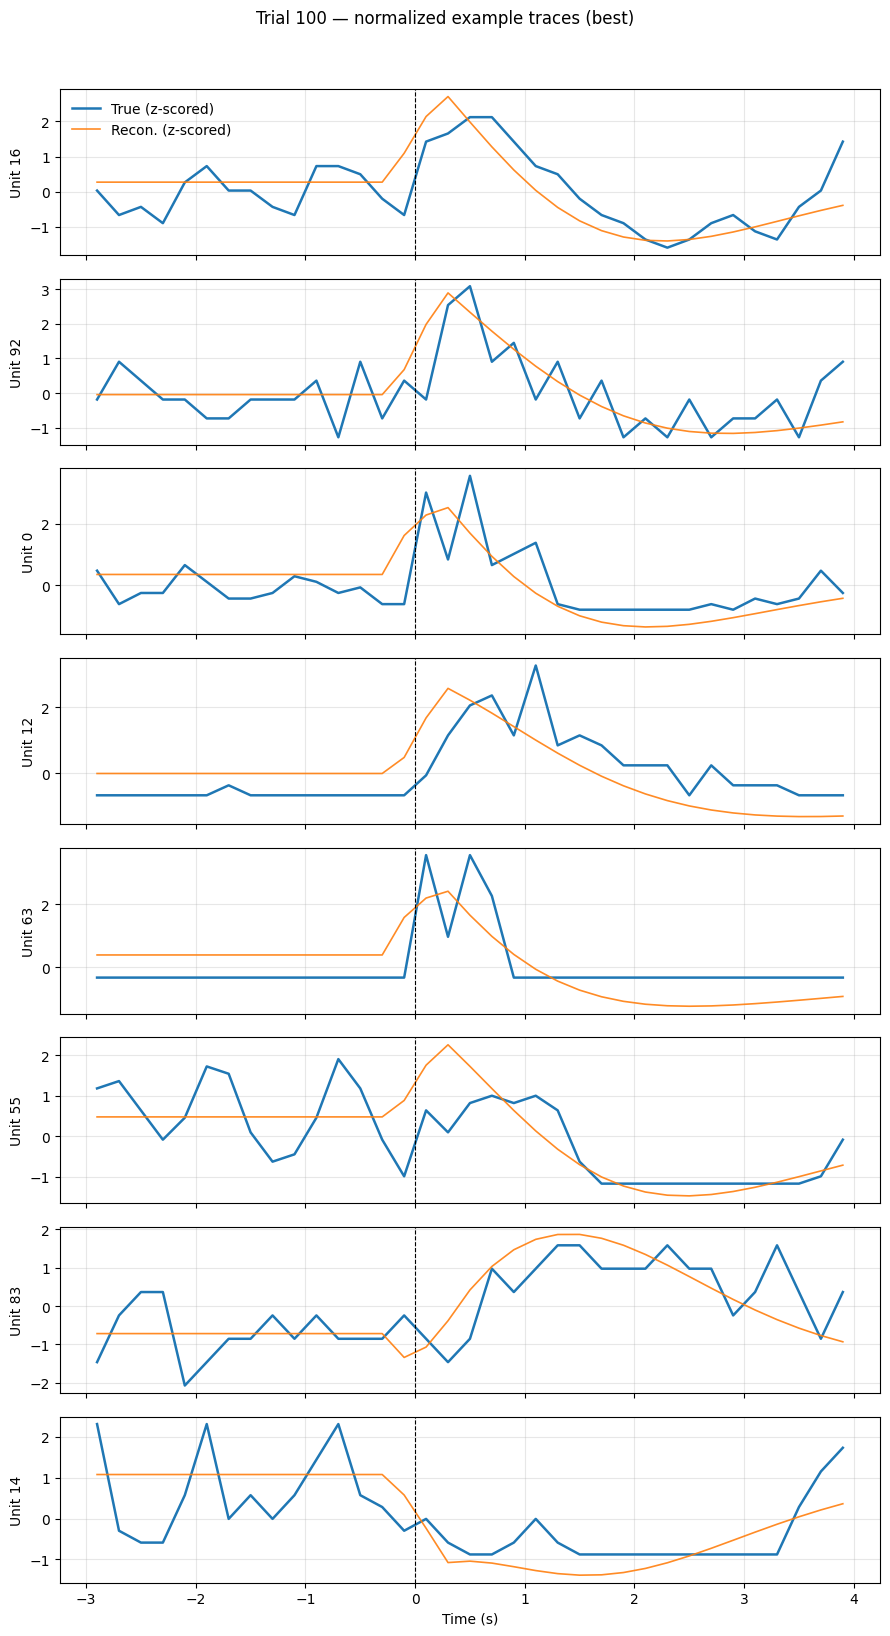

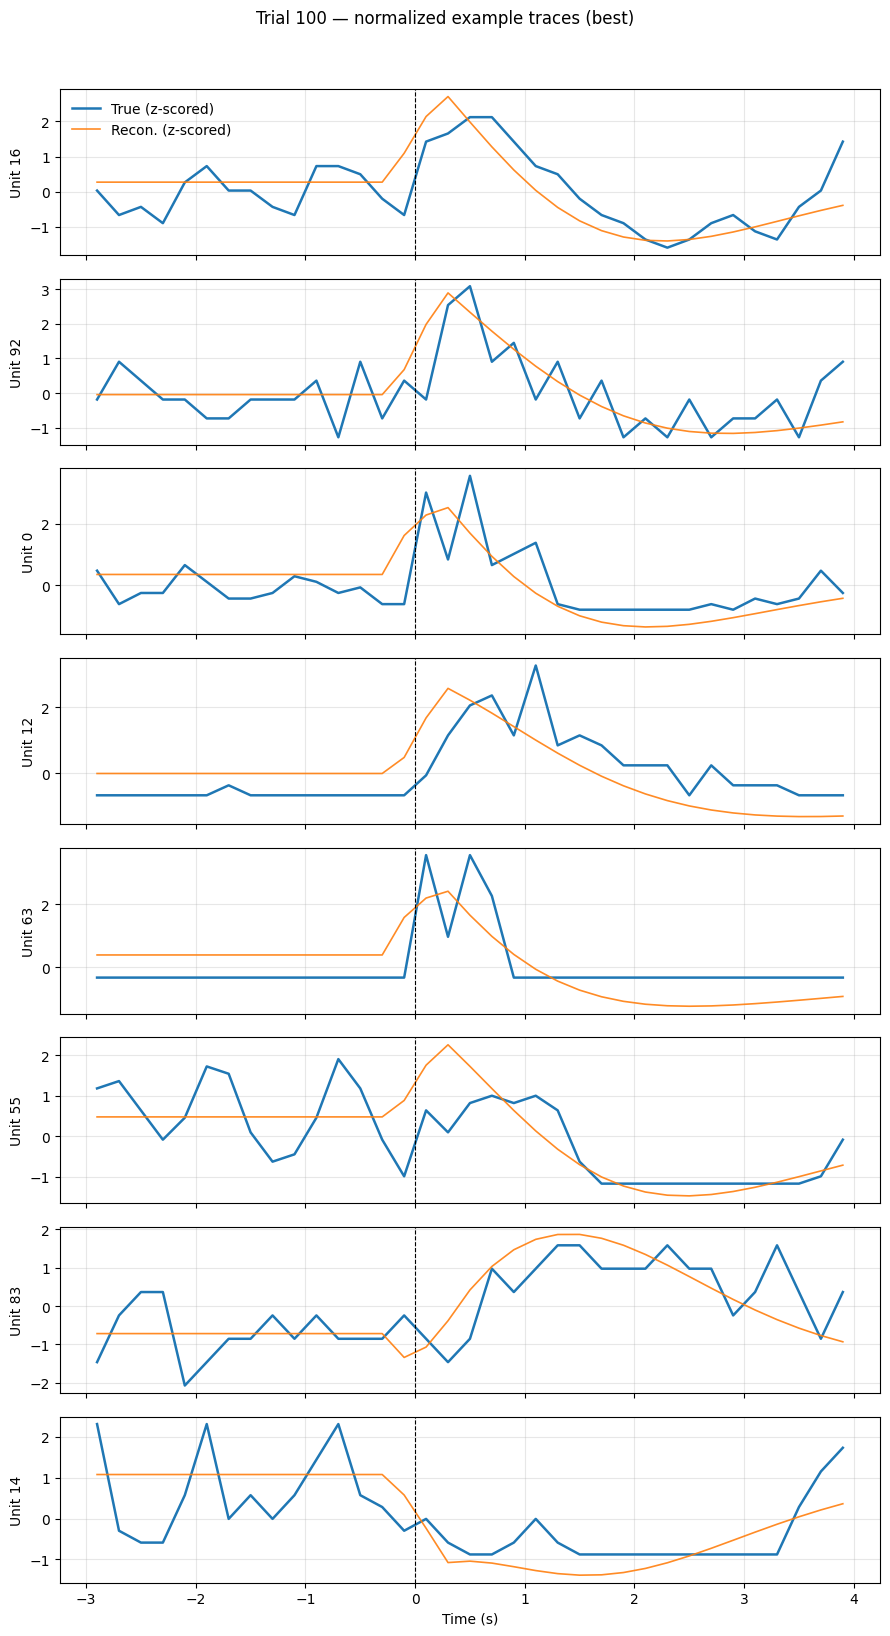

In [144]:
print("Mean firing per unit:", Y_trials.mean(axis=(1,2))[:100])
print("Std per unit:", Y_trials.std(axis=(1,2))[:100])

if np.nanmean(Y_trials) < 1e-3:
    print("⚠️ Detected near-zero values; rescaling up by 1e7")
    Y_trials *= 1e7

plot_example_traces_normalized(res, Y_trials, t_rel, trial_idx=100, mode="best", n=8)


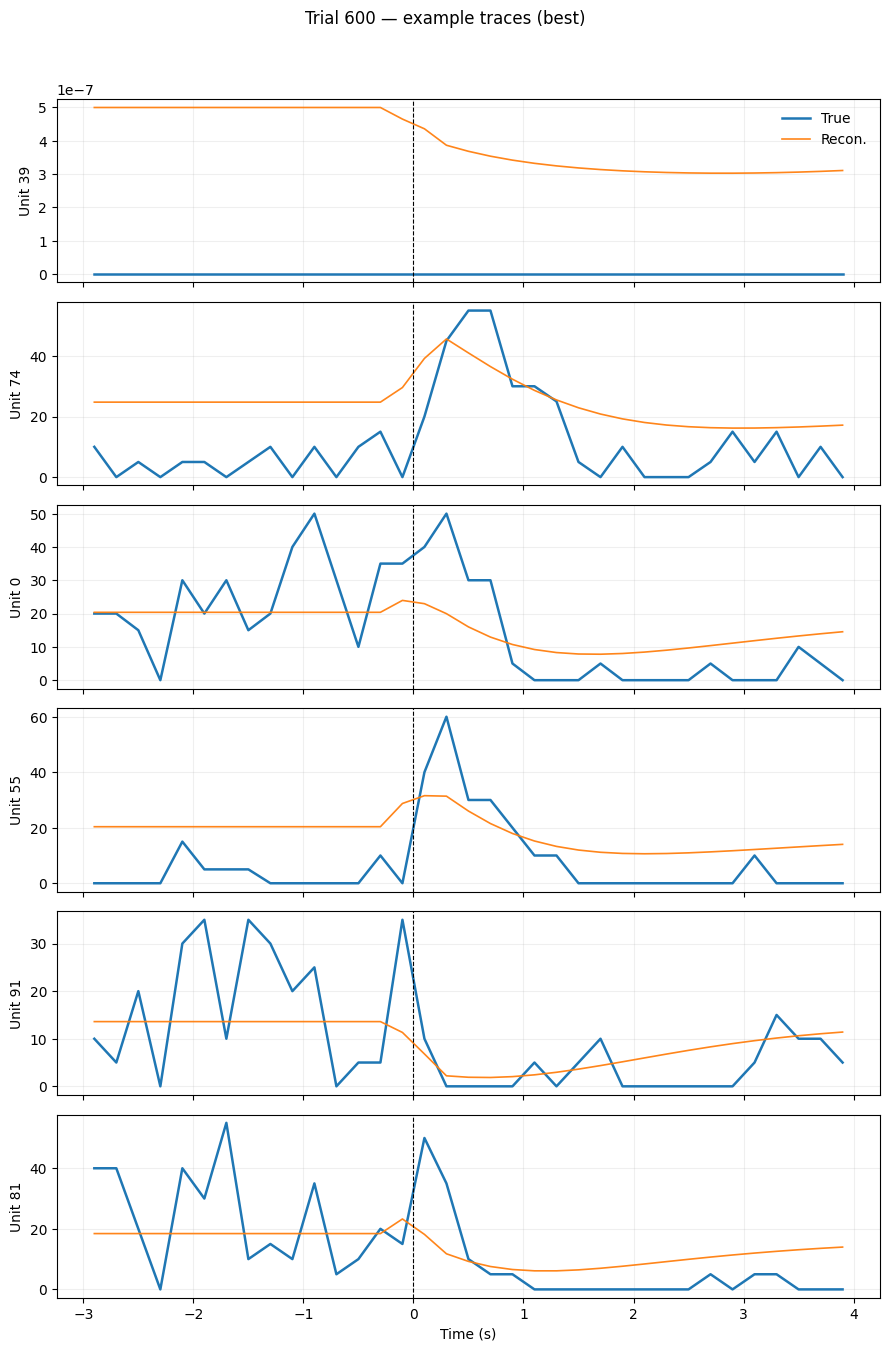

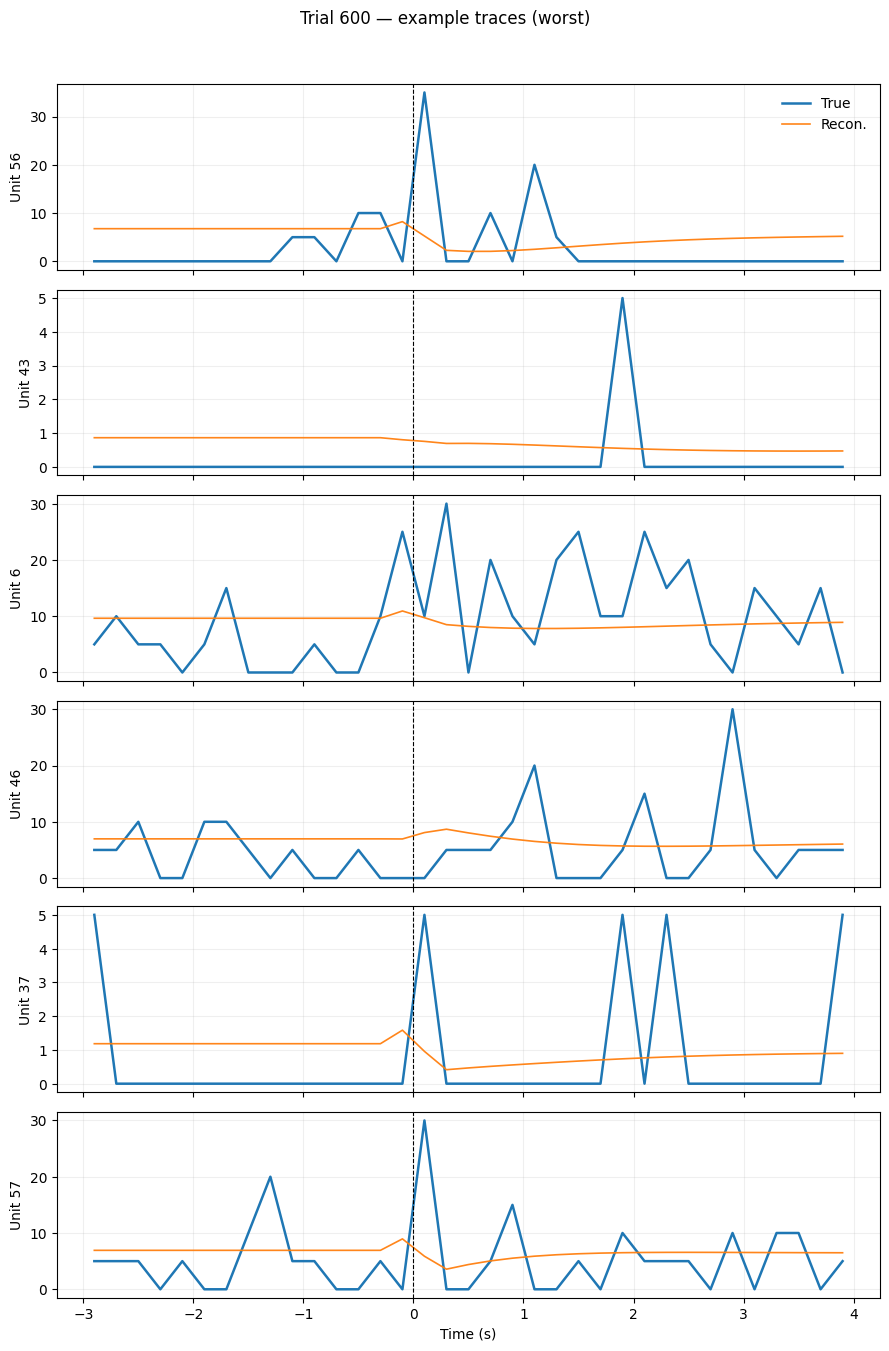

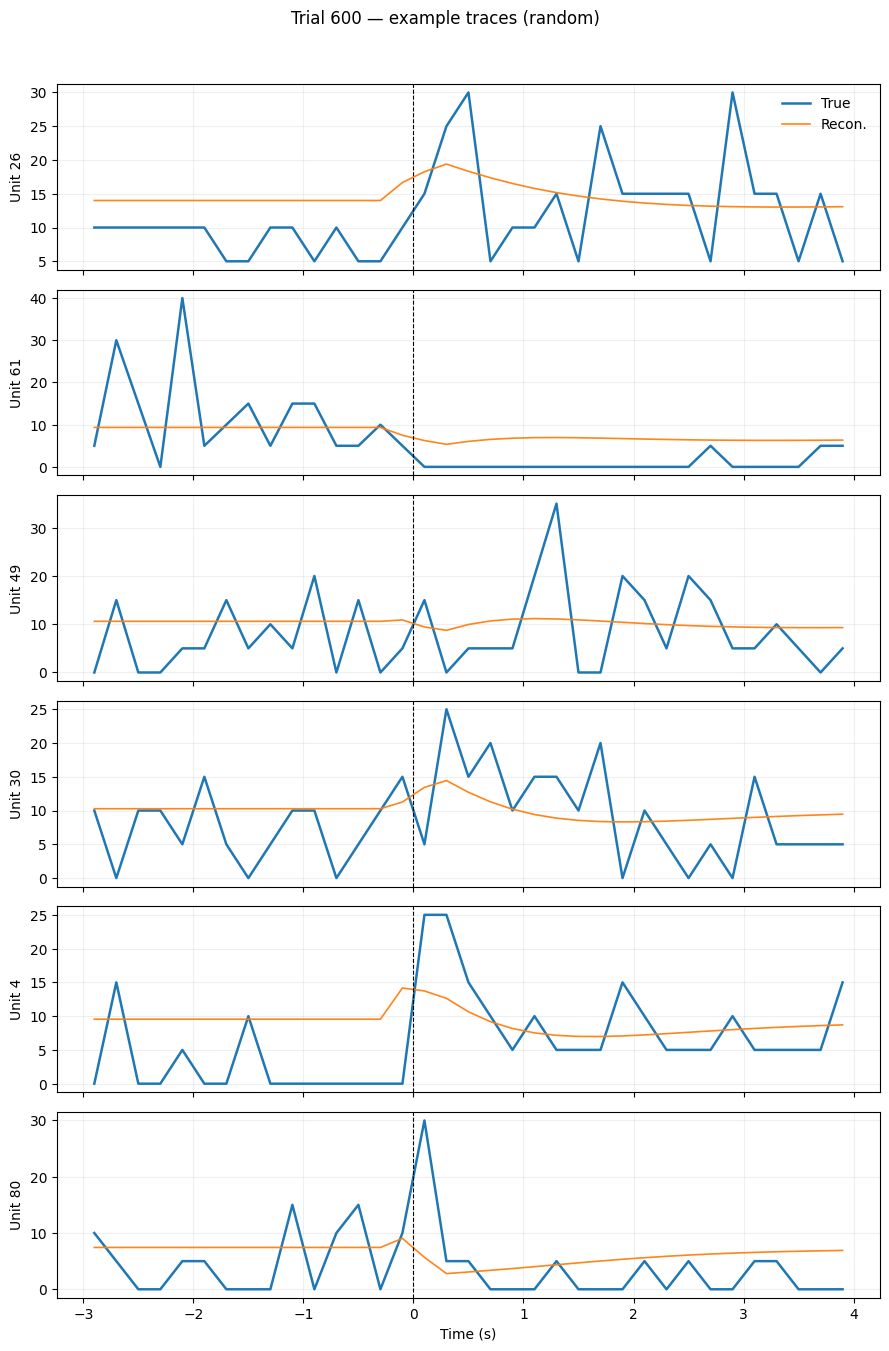

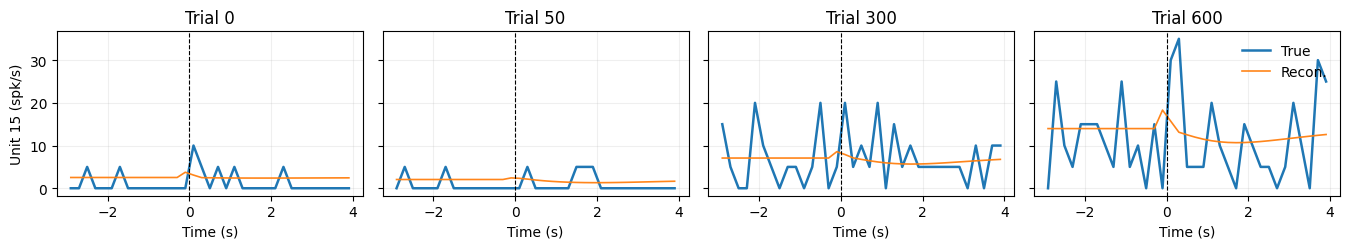

In [145]:
# 1) Show the best 6 units (by per-unit R²) for a given trial:
plot_example_traces(res, Y_trials, t_rel, trial_idx=600, n=6, mode="best");

# 2) Or the worst 6:
plot_example_traces(res, Y_trials, t_rel, trial_idx=600, n=6, mode="worst");

# 3) Random 6:
plot_example_traces(res, Y_trials, t_rel, trial_idx=600, n=6, mode="random");

# 4) Follow one unit across several trials:
plot_unit_across_trials(res, Y_trials, t_rel, unit_id=15, trial_indices=[0, 50, 300, 600]);


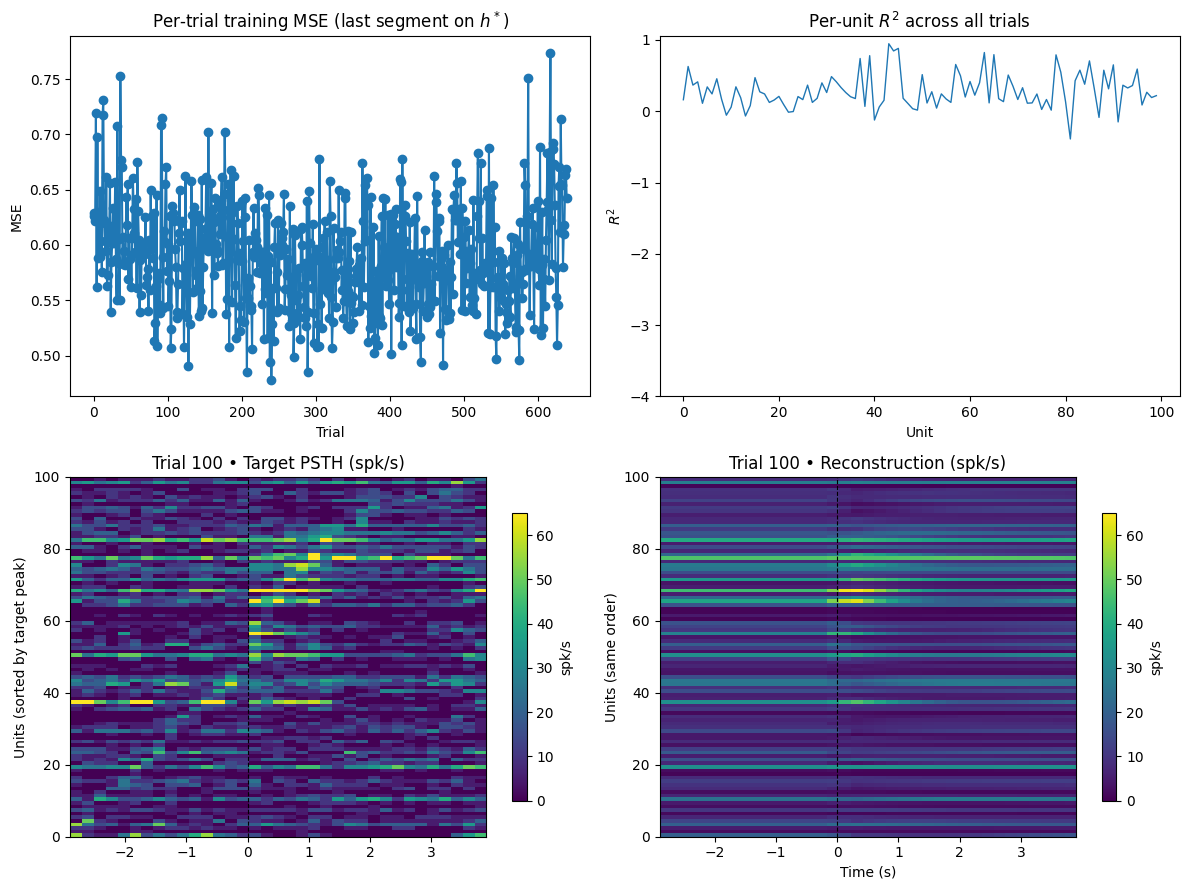

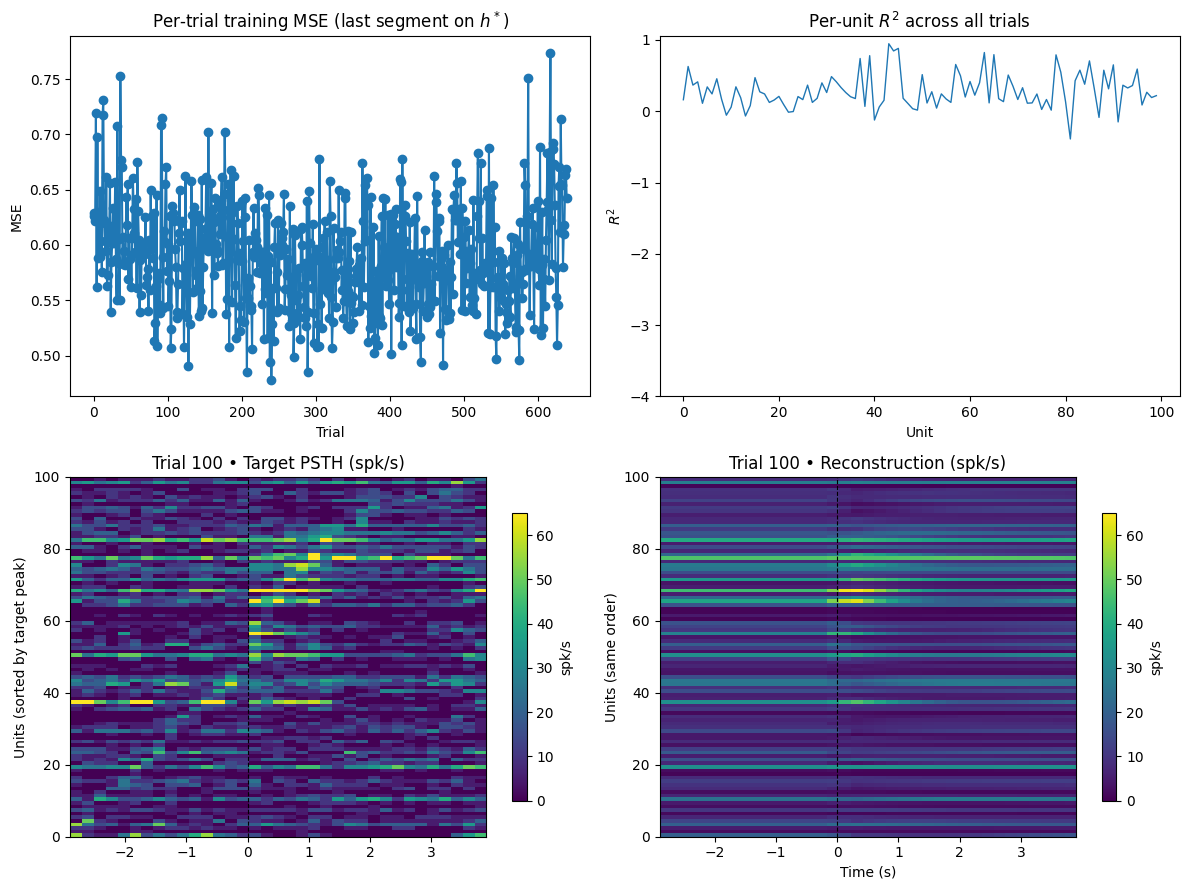

In [146]:
# Summary comparing original vs reconstruction for a chosen trial
plot_fit_summary_with_original_from_result(
    res, Y_trials, t_rel, progress=progress, trial_to_show=100, max_units_for_heatmap=100
)